# Lorenz (1963): Deterministic Nonperiodic Flow

A three-variable ODE system exhibiting deterministic chaos, derived as a minimal model of
atmospheric convection. This notebook covers the canonical system, externally forced dynamics,
and time-varying parameters.

## Background

Lorenz (1963) derived a three-mode truncation of the Navier–Stokes equations for
Rayleigh–Bénard convection — a fluid layer heated from below. Despite having only three
degrees of freedom, the system produces bounded, non-periodic trajectories that are
exponentially sensitive to initial conditions: the defining signature of **deterministic chaos**.

The key results reproduced here:

| Section | Content |
|---------|----------|
| Canonical | Irregular oscillations (cf. Fig. 1); butterfly attractor (cf. Fig. 2); sensitive dependence on ICs |
| Forced | Additive sinusoidal term on $dx/dt$; distortion of the attractor geometry |
| Time-varying params | $\sigma(t)$ and $\rho(t)$ as callables; trajectory colored by $\rho(t)$ to show regime shifts |

## Literature

Lorenz, E. N. (1963). Deterministic Nonperiodic Flow. *J. Atmos. Sci.*, 20, 130–141.
https://doi.org/10.1175/1520-0469_1963_020_0130_dnf_2_0_co_2

## Equations

$$
\frac{dx}{dt} = \sigma(y - x) + f(t)
$$

$$
\frac{dy}{dt} = x(\rho - z) - y
$$

$$
\frac{dz}{dt} = xy - \beta z
$$

The optional forcing term $f(t)$ is added only to $dx/dt$ when a scalar `Forcing` is supplied
(a 3-element `Forcing` adds component-wise to all three equations).
Setting `forcing=None` recovers the unforced system.

| Symbol | Variable | Physical meaning |
|--------|----------|------------------|
| $x$ | `x` | Rate of convective overturning |
| $y$ | `y` | Horizontal temperature contrast |
| $z$ | `z` | Vertical temperature deviation from linearity |

## Parameters

| Symbol | Key | Default | Physical meaning |
|--------|-----|---------|------------------|
| $\sigma$ | `sigma` | 10.0 | Prandtl number (viscosity / thermal diffusivity) |
| $\rho$ | `rho` | 28.0 | Normalized Rayleigh number; chaos onset at $\rho \approx 24.74$ |
| $\beta$ | `beta` | 8/3 | Geometric factor (convection cell aspect ratio) |

All three parameters accept scalars, callables `(t)` / `(t, state)` / `(t, state, model)`,
or `pb.core.Forcing` objects — time-varying parameters are resolved at each solver step.

**Chaos onset:** with $\sigma = 10$, $\beta = 8/3$, the system is chaotic for $\rho > 24.74$.
For $\rho < 1$ the origin is the only fixed point; for $1 < \rho < 24.74$ there are two
stable fixed points (convective rolls).

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import climatecritters as pb
from climatecritters.signal_models import Lorenz63

## Part 1 — Canonical System

Canonical parameters from Lorenz (1963): $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.
Initial conditions $(-8, 8, 27)$ place the trajectory close to but off the attractor,
giving a short transient of roughly 2–3 time units before the irregular oscillations appear.

In [10]:
sigma_c, rho_c, beta_c = 10.0, 28.0, 8/3
y0_c = [-8.0, 8.0, 27.0]
t_span_c = (0, 50)

model_c = Lorenz63(forcing=None, sigma=sigma_c, rho=rho_c, beta=beta_c)
model_c.integrate(t_span=t_span_c, y0=y0_c, method='RK45')

t_eval_c = pb.utils.define_t_eval(t_span_c, delta_t=0.01)
state_c = model_c.reframe_time_axis(t_eval_c)
t_c = np.asarray(model_c.time)

### 1.1 Irregular oscillations — cf. Lorenz (1963) Figure 1

Lorenz's Figure 1 shows the time evolution of the convective overturning variable,
demonstrating non-periodicity: the trajectory oscillates irregularly between positive
and negative excursions without ever exactly repeating. All three variables are shown
to make the non-periodicity unambiguous.

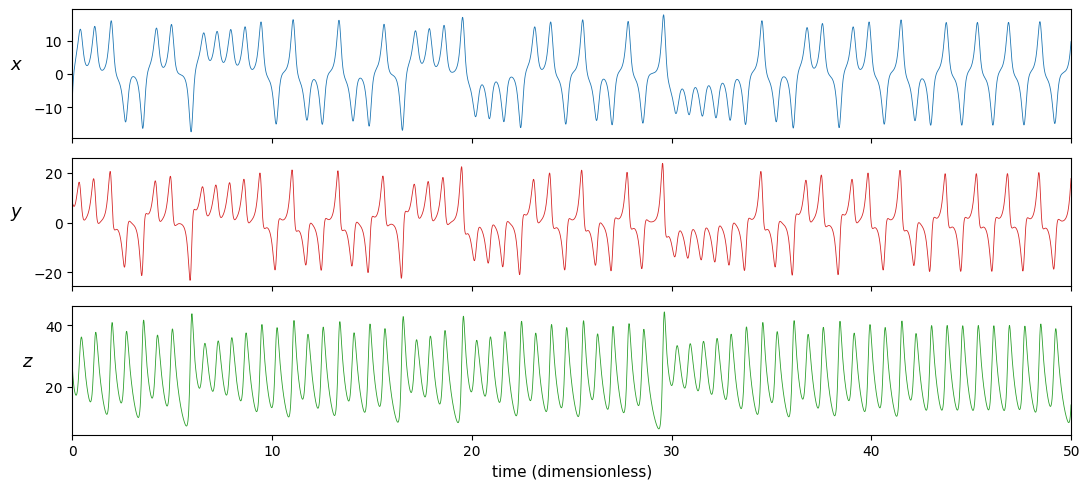

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
labels  = ['$x$', '$y$', '$z$']
colors  = ['#1f77b4', '#d62728', '#2ca02c']

for ax, var, label, color in zip(axes, ['x', 'y', 'z'], labels, colors):
    ax.plot(t_c, state_c[var], lw=0.6, color=color)
    ax.set_ylabel(label, fontsize=13, rotation=0, labelpad=12)
    ax.set_xlim(t_span_c)

axes[-1].set_xlabel('time (dimensionless)', fontsize=11)
plt.tight_layout()
plt.show()

### 1.2 Butterfly attractor — cf. Lorenz (1963) Figure 2

Lorenz's Figure 2 shows the trajectory projected onto the $y$–$z$ plane, revealing
the two-lobed structure later named the **butterfly attractor**. The trajectory winds
around one lobe for an unpredictable number of revolutions before switching to the other,
never visiting the exact same point twice. The $x$–$z$ projection (right) makes the
bilateral symmetry most visible. Colour encodes time.

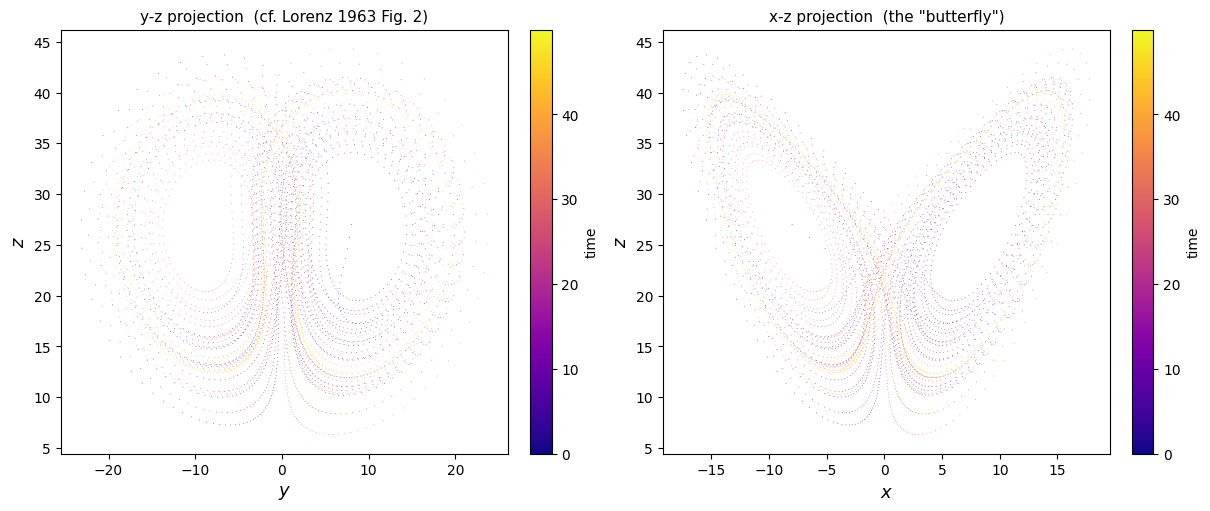

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

sc0 = axes[0].scatter(state_c['y'], state_c['z'], c=t_c, cmap='plasma', s=0.3, lw=0)
fig.colorbar(sc0, ax=axes[0], label='time')
axes[0].set_xlabel('$y$', fontsize=13)
axes[0].set_ylabel('$z$', fontsize=13)
axes[0].set_title('y-z projection  (cf. Lorenz 1963 Fig. 2)', fontsize=11)

sc1 = axes[1].scatter(state_c['x'], state_c['z'], c=t_c, cmap='plasma', s=0.3, lw=0)
fig.colorbar(sc1, ax=axes[1], label='time')
axes[1].set_xlabel('$x$', fontsize=13)
axes[1].set_ylabel('$z$', fontsize=13)
axes[1].set_title('x-z projection  (the "butterfly")', fontsize=11)

plt.show()

---
## Part 2 — Forced System

An additive sinusoidal term is applied to $dx/dt$, representing external modulation
of the convective overturning rate. A scalar `Forcing` object is passed; the model
adds it only to the $x$ equation.

$$
\frac{dx}{dt} = \sigma(y - x) + A\sin\!\left(\frac{2\pi t}{T}\right)
$$

The comparison plot below shows both the time series (with $f(t)$ overlaid) and the
phase portrait side-by-side, making the forcing-induced distortion of the attractor
geometry immediately visible.

In [20]:
A_f, T_f = 2.0, 12.0

def forcing_func(t):
    return A_f * np.sin(2 * np.pi * t / T_f)

model_f = Lorenz63(forcing=pb.core.Forcing(forcing_func),
                   sigma=sigma_c, rho=rho_c, beta=beta_c)
model_f.integrate(t_span=t_span_c, y0=y0_c, method='RK45')
state_f = model_f.reframe_time_axis(t_eval_c)
t_f = np.asarray(model_f.time)
F_trace = np.array([forcing_func(ti) for ti in t_f])

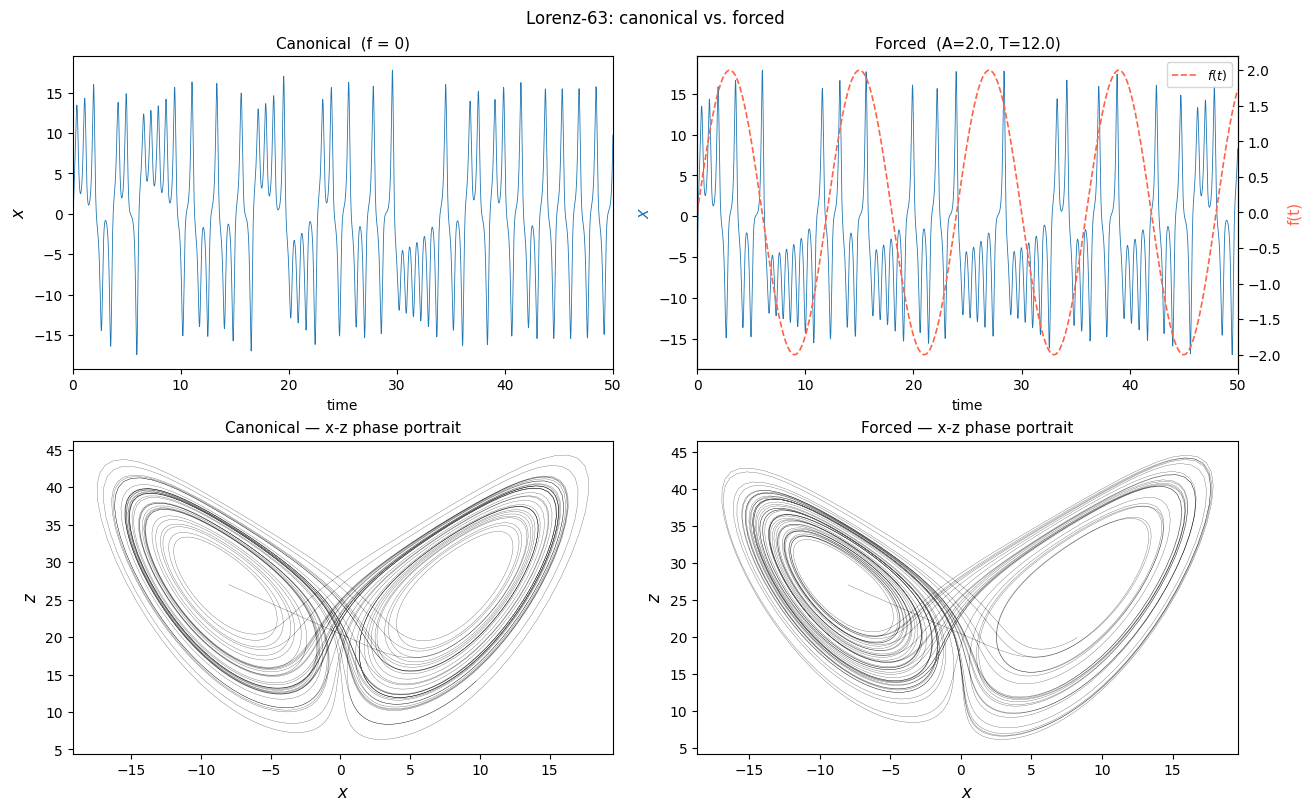

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

# top row: x time series — canonical and forced
axes[0, 0].plot(t_c, state_c['x'], lw=0.6, color='#1f77b4')
axes[0, 0].set_ylabel('$x$', fontsize=12)
axes[0, 0].set_title('Canonical  (f = 0)', fontsize=11)
axes[0, 0].set_xlim(t_span_c)

ax_twin = axes[0, 1].twinx()
axes[0, 1].plot(t_f, state_f['x'], lw=0.6, color='#1f77b4', label='$x$')
ax_twin.plot(t_f, F_trace, lw=1.2, color='tomato', ls='--', label='$f(t)$')
axes[0, 1].set_ylabel('$x$', color='#1f77b4', fontsize=12)
ax_twin.set_ylabel('f(t)', color='tomato', fontsize=11)
axes[0, 1].set_title(f'Forced  (A={A_f}, T={T_f})', fontsize=11)
axes[0, 1].set_xlim(t_span_c)
ax_twin.legend(loc='upper right', fontsize=9)

for ax in axes[0]:
    ax.set_xlabel('time', fontsize=10)

# bottom row: x-z phase portraits
for ax, state, label in zip(axes[1], [state_c, state_f], ['Canonical', 'Forced']):
    ax.plot(state['x'], state['z'], lw=0.25, color='#333333', alpha=0.8)
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$z$', fontsize=12)
    ax.set_title(f'{label} — x-z phase portrait', fontsize=11)

plt.suptitle('Lorenz-63: canonical vs. forced', fontsize=12)
plt.show()

## Part 3 — Time-Varying Parameters

Any parameter ($\sigma$, $\rho$, $\beta$) can be passed as a callable and is resolved
at each solver step. This makes it straightforward to sweep through parameter regimes
or model slow environmental changes.

Here $\sigma(t)$ oscillates gently around the canonical value, while $\rho(t)$ varies
more broadly — periodically crossing the chaos boundary near $\rho \approx 24.74$.

$$
\sigma(t) = 10 + 2\sin\!\left(\frac{2\pi t}{10}\right), \qquad
\rho(t) = 28 + 5\sin\!\left(\frac{2\pi t}{20}\right)
$$

The phase portrait is coloured by $\rho(t)$, showing which parts of the attractor are
visited under which Rayleigh regime.

In [ ]:
def sigma_func(t):
    return 10.0 + 2.0 * np.sin(2 * np.pi * t / 10.0)

def rho_func(t):
    return 28.0 + 5.0 * np.sin(2 * np.pi * t / 20.0)

model_tv = Lorenz63(forcing=None, sigma=sigma_func, rho=rho_func, beta=beta_c)
model_tv.integrate(t_span=t_span_c, y0=y0_c, method='RK45')
state_tv = model_tv.reframe_time_axis(t_eval_c)
t_tv = np.asarray(model_tv.time)

sigma_trace = np.array([sigma_func(ti) for ti in t_tv])
rho_trace   = np.array([rho_func(ti)   for ti in t_tv])

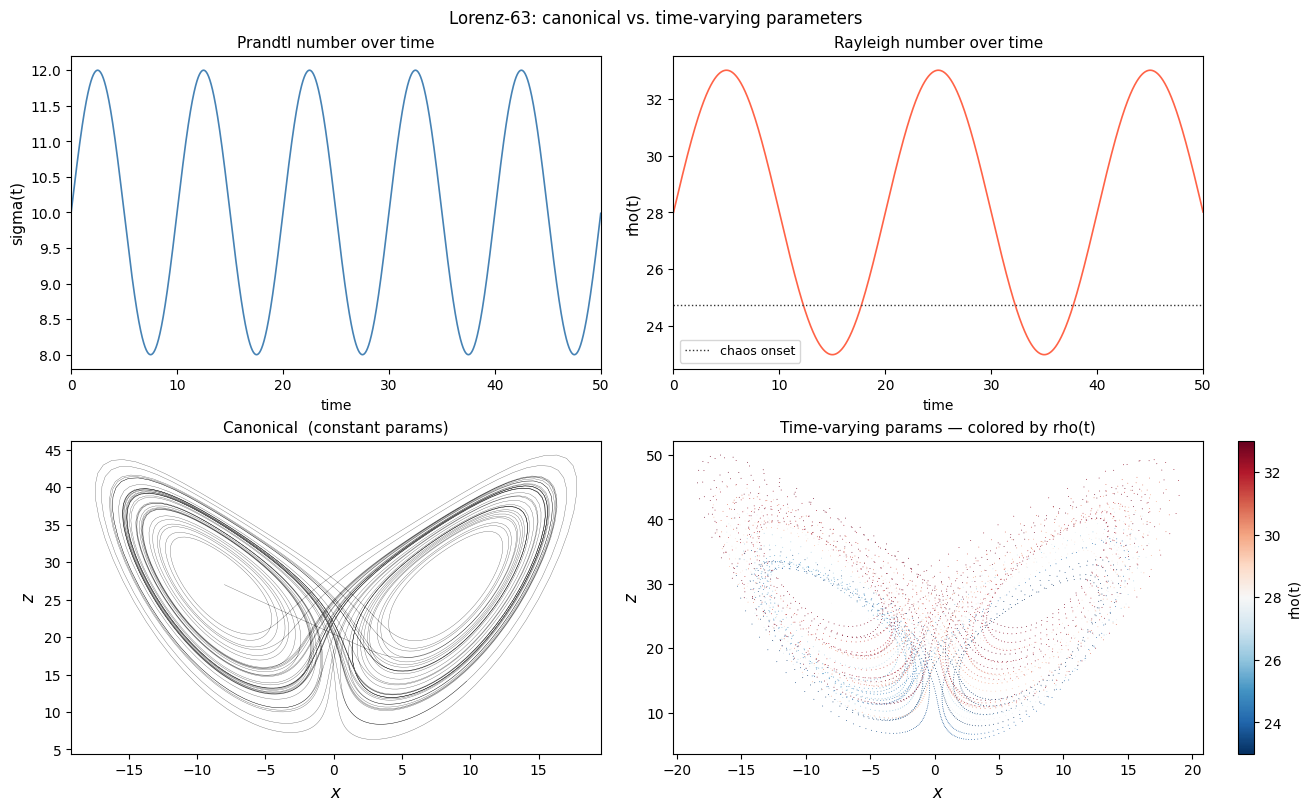

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

# top row: parameter traces
axes[0, 0].plot(t_tv, sigma_trace, color='steelblue', lw=1.2)
axes[0, 0].set_ylabel('sigma(t)', fontsize=11)
axes[0, 0].set_title('Prandtl number over time', fontsize=11)
axes[0, 0].set_xlim(t_span_c)

axes[0, 1].plot(t_tv, rho_trace, color='tomato', lw=1.2)
axes[0, 1].axhline(24.74, color='#333333', ls=':', lw=1.0, label='chaos onset')
axes[0, 1].set_ylabel('rho(t)', fontsize=11)
axes[0, 1].set_title('Rayleigh number over time', fontsize=11)
axes[0, 1].set_xlim(t_span_c)
axes[0, 1].legend(fontsize=9)

for ax in axes[0]:
    ax.set_xlabel('time', fontsize=10)

# bottom row: phase portraits
axes[1, 0].plot(state_c['x'], state_c['z'], lw=0.25, color='#333333', alpha=0.8)
axes[1, 0].set_xlabel('$x$', fontsize=12)
axes[1, 0].set_ylabel('$z$', fontsize=12)
axes[1, 0].set_title('Canonical  (constant params)', fontsize=11)

sc = axes[1, 1].scatter(state_tv['x'], state_tv['z'],
                        c=rho_trace, cmap='RdBu_r', s=0.4, lw=0)
fig.colorbar(sc, ax=axes[1, 1], label='rho(t)')
axes[1, 1].set_xlabel('$x$', fontsize=12)
axes[1, 1].set_ylabel('$z$', fontsize=12)
axes[1, 1].set_title('Time-varying params — colored by rho(t)', fontsize=11)

plt.suptitle('Lorenz-63: canonical vs. time-varying parameters', fontsize=12)
plt.show()

## Implementation Notes

- **Solver:** `RK45` is the recommended solver; the system is smooth and continuous.
  Unlike `Lorenz96`, this class accumulates `state_variables` inside `dydt` rather than
  using the post-history hook, so `reframe_time_axis(t_eval)` is needed after integration
  to obtain output on a uniform time grid.
- **Forcing:** a scalar `Forcing` adds to $dx/dt$ only; a 3-element array `Forcing` adds
  component-wise to all three equations. `forcing=None` is equivalent to zero forcing.
- **Time-varying parameters:** pass any callable with signature `(t)`, `(t, state)`, or
  `(t, state, model)` for `sigma`, `rho`, or `beta`. The model resolves them at each
  solver evaluation, so adaptive step-size control in RK45 handles stiff transitions
  gracefully.
- **Chaos boundary:** with canonical $\sigma$ and $\beta$, the system transitions to chaos
  at $\rho \approx 24.74$. When $\rho(t)$ crosses this boundary the trajectory can
  temporarily collapse toward a fixed point before re-entering chaotic motion.
- **Related:** `lorenz96.ipynb` extends this structure to $n$ variables on a periodic ring,
  with an optional two-scale fast-variable layer.